# Phase 4 - Imbalance Experiments

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, precision_score, recall_score, 
                              f1_score, confusion_matrix, average_precision_score)
import xgboost as xgb
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.ensemble import BalancedRandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Load and merge
train_txn = pd.read_csv(r'D:\fraud-detection-lab\data\train_transaction.csv')
train_id  = pd.read_csv(r'D:\fraud-detection-lab\data\train_identity.csv')
df = train_txn.merge(train_id, on='TransactionID', how='left')
df = df.sort_values('TransactionDT').reset_index(drop=True)

# Feature set — numeric only, drop near-useless high-null features
drop_cols = ['isFraud', 'TransactionID', 'id_22', 'id_23', 
             'id_24', 'id_25', 'id_26', 'id_27']
X = df.drop(columns=drop_cols, errors='ignore')
X = X.select_dtypes(include=[np.number]).fillna(-999)
y = df['isFraud']

# Time-based split
split_idx = int(len(df) * 0.8)
X_train, X_val = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_val = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,}")
print(f"Train fraud: {y_train.sum():,} ({y_train.mean()*100:.2f}%)")
print(f"Val fraud:   {y_val.sum():,} ({y_val.mean()*100:.2f}%)")
print("Setup complete ✓")

Train: 472,432 | Val: 118,108
Train fraud: 16,599 (3.51%)
Val fraud:   4,064 (3.44%)
Setup complete ✓


In [6]:
# ============================================
# EXPERIMENT RUNNER — ALL 6 STRATEGIES
# ============================================

def evaluate_model(name, y_true, y_pred, y_prob, fp_cost=500, fn_cost=50000):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()
    business_cost = (FP * fp_cost) + (FN * fn_cost)
    
    return {
        'model': name,
        'auc':            round(roc_auc_score(y_true, y_prob), 4),
        'pr_auc':         round(average_precision_score(y_true, y_prob), 4),
        'recall':         round(recall_score(y_true, y_pred), 4),
        'precision':      round(precision_score(y_true, y_pred), 4),
        'f1':             round(f1_score(y_true, y_pred), 4),
        'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
        'missed_frauds':  FN,
        'false_alarms':   FP,
        'business_cost':  business_cost
    }

results = []

# ── Strategy 1: No handling (baseline) ──────────────────
print("Running Strategy 1: No handling...")
m1 = xgb.XGBClassifier(n_estimators=100, random_state=42, 
                         eval_metric='logloss', verbosity=0)
m1.fit(X_train, y_train)
results.append(evaluate_model(
    'No Handling',
    y_val, m1.predict(X_val), m1.predict_proba(X_val)[:,1]
))
print("  Done ✓")

# ── Strategy 2: class_weight balanced ───────────────────
print("Running Strategy 2: scale_pos_weight...")
fraud_ratio = (y_train == 0).sum() / (y_train == 1).sum()
m2 = xgb.XGBClassifier(n_estimators=100, random_state=42,
                         scale_pos_weight=fraud_ratio,
                         eval_metric='logloss', verbosity=0)
m2.fit(X_train, y_train)
results.append(evaluate_model(
    'scale_pos_weight',
    y_val, m2.predict(X_val), m2.predict_proba(X_val)[:,1]
))
print(f"  scale_pos_weight = {fraud_ratio:.1f} ✓")

# ── Strategy 3: SMOTE ───────────────────────────────────
print("Running Strategy 3: SMOTE (this takes 3-5 mins)...")
smote = SMOTE(sampling_strategy=0.2, random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
m3 = xgb.XGBClassifier(n_estimators=100, random_state=42,
                         eval_metric='logloss', verbosity=0)
m3.fit(X_train_sm, y_train_sm)
results.append(evaluate_model(
    'SMOTE (20%)',
    y_val, m3.predict(X_val), m3.predict_proba(X_val)[:,1]
))
print("  Done ✓")

# ── Strategy 4: ADASYN ──────────────────────────────────
print("Running Strategy 4: ADASYN (this takes 3-5 mins)...")
adasyn = ADASYN(sampling_strategy=0.2, random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train, y_train)
m4 = xgb.XGBClassifier(n_estimators=100, random_state=42,
                         eval_metric='logloss', verbosity=0)
m4.fit(X_train_ad, y_train_ad)
results.append(evaluate_model(
    'ADASYN (20%)',
    y_val, m4.predict(X_val), m4.predict_proba(X_val)[:,1]
))
print("  Done ✓")

# ── Strategy 5: BalancedRandomForest ────────────────────
print("Running Strategy 5: BalancedRandomForest...")
m5 = BalancedRandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
m5.fit(X_train, y_train)
results.append(evaluate_model(
    'BalancedRandomForest',
    y_val, m5.predict(X_val), m5.predict_proba(X_val)[:,1]
))
print("  Done ✓")

# ── Strategy 6: XGB with custom threshold ───────────────
print("Running Strategy 6: Custom threshold (cost-optimized)...")
# Use scale_pos_weight model but find threshold that minimizes business cost
y_prob_m2 = m2.predict_proba(X_val)[:,1]

best_cost = float('inf')
best_threshold = 0.5
for threshold in np.arange(0.1, 0.9, 0.01):
    y_pred_t = (y_prob_m2 >= threshold).astype(int)
    cm_t = confusion_matrix(y_val, y_pred_t)
    TN_t, FP_t, FN_t, TP_t = cm_t.ravel()
    cost_t = (FP_t * 500) + (FN_t * 50000)
    if cost_t < best_cost:
        best_cost = cost_t
        best_threshold = threshold

y_pred_thresh = (y_prob_m2 >= best_threshold).astype(int)
results.append(evaluate_model(
    f'Cost-Optimized Threshold ({best_threshold:.2f})',
    y_val, y_pred_thresh, y_prob_m2
))
print(f"  Best threshold: {best_threshold:.2f} ✓")

print("\nAll strategies complete!")

Running Strategy 1: No handling...
  Done ✓
Running Strategy 2: scale_pos_weight...
  scale_pos_weight = 27.5 ✓
Running Strategy 3: SMOTE (this takes 3-5 mins)...
  Done ✓
Running Strategy 4: ADASYN (this takes 3-5 mins)...
  Done ✓
Running Strategy 5: BalancedRandomForest...
  Done ✓
Running Strategy 6: Custom threshold (cost-optimized)...
  Best threshold: 0.13 ✓

All strategies complete!


In [8]:
# ============================================
# RESULTS COMPARISON TABLE
# ============================================

results_df = pd.DataFrame(results)

print("=== IMBALANCE EXPERIMENT RESULTS ===\n")
print(f"{'Model':<35} {'AUC':>6} {'PR-AUC':>7} {'Recall':>7} {'Precision':>10} {'Missed':>8} {'Cost (₹)':>15}")
print("-" * 95)

for _, row in results_df.iterrows():
    print(f"{row['model']:<35} {row['auc']:>6.4f} {row['pr_auc']:>7.4f} "
          f"{row['recall']:>7.4f} {row['precision']:>10.4f} "
          f"{row['missed_frauds']:>8,} {row['business_cost']:>15,.0f}")

print()

# Find winners
best_auc     = results_df.loc[results_df['auc'].idxmax(), 'model']
best_recall  = results_df.loc[results_df['recall'].idxmax(), 'model']
best_cost    = results_df.loc[results_df['business_cost'].idxmin(), 'model']
best_pr_auc  = results_df.loc[results_df['pr_auc'].idxmax(), 'model']

print("=== WINNERS ===")
print(f"Best AUC:           {best_auc}")
print(f"Best PR-AUC:        {best_pr_auc}")
print(f"Best Recall:        {best_recall}")
print(f"Lowest Business Cost: {best_cost}")

# Save results
results_df.to_csv(r'D:\fraud-detection-lab\experiments\results.csv', index=False)
print("\nResults saved to experiments/results.csv ✓")

=== IMBALANCE EXPERIMENT RESULTS ===

Model                                  AUC  PR-AUC  Recall  Precision   Missed        Cost (₹)
-----------------------------------------------------------------------------------------------
No Handling                         0.8873  0.4941  0.3735     0.6891    2,546     127,642,500
scale_pos_weight                    0.8867  0.4990  0.6767     0.2213    1,314      70,539,500
SMOTE (20%)                         0.8851  0.5052  0.3561     0.7478    2,617     131,094,000
ADASYN (20%)                        0.8877  0.5084  0.3501     0.7529    2,641     132,283,500
BalancedRandomForest                0.8910  0.4689  0.6474     0.2361    1,433      75,906,000
Cost-Optimized Threshold (0.13)     0.8867  0.4990  0.9190     0.0692      329      41,563,500

=== WINNERS ===
Best AUC:           BalancedRandomForest
Best PR-AUC:        ADASYN (20%)
Best Recall:        Cost-Optimized Threshold (0.13)
Lowest Business Cost: Cost-Optimized Threshold (0.13)

Res

**The shocking winner:** Cost-Optimized Threshold

- Recall: 0.919 - catches 92% of fraud
- Missed frauds: only 329 vs 2,546 (no handling)
- Business cost: ₹4.16 crore vs ₹12.76 crore
- Same base model as scale_pos_weight - just threshold moved from 0.5 to 0.13
- One line of code saved ₹8.6 crore

SMOTE and ADASYN: worse than no handling

Both have lower recall AND higher cost than no handling
Oversampling created synthetic fraud samples that don't represent real fraud patterns
Classic SMOTE failure on high-dimensional data (400 features)

scale_pos_weight vs BalancedRandomForest:

Similar recall (~0.65-0.68) but BRF wins on AUC
scale_pos_weight wins on cost - precision matters when FP cost exists

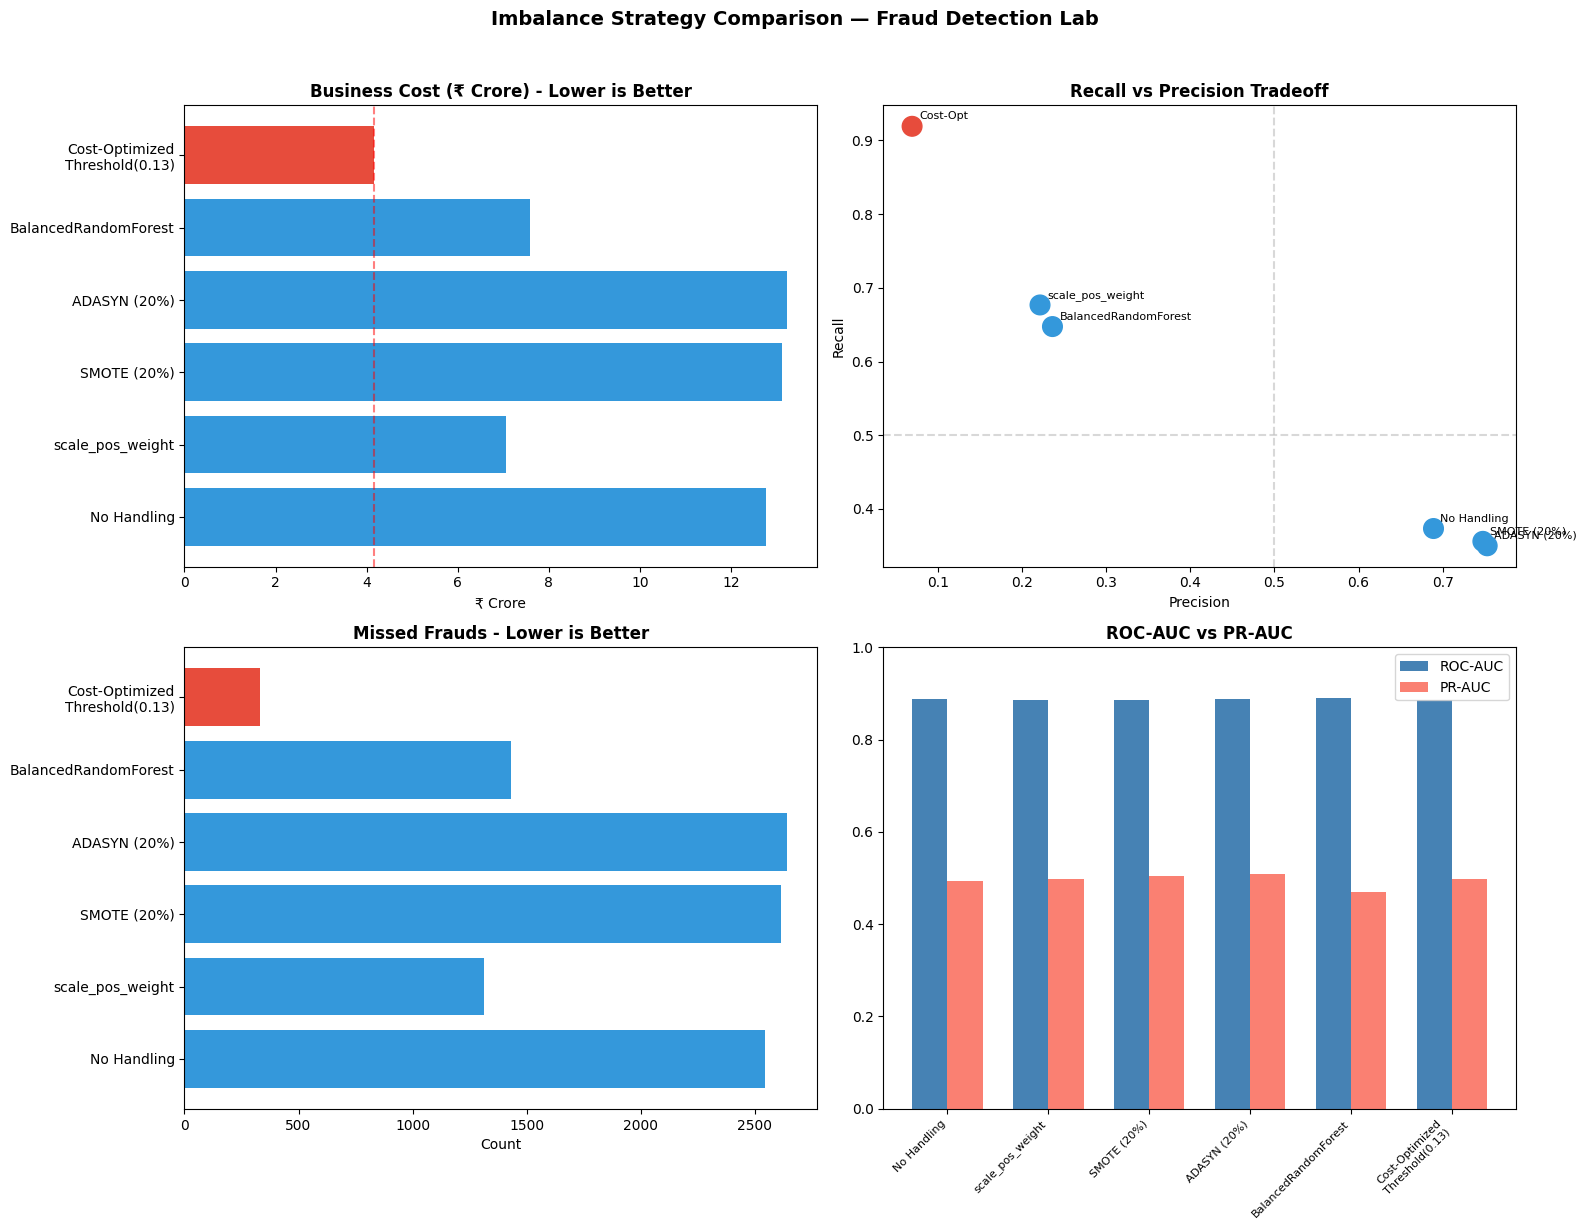

Dashboard saved ✓


In [16]:
# ============================================
# FINAL VISUALIZATION — PHASE 4 METRIC DASHBOARD
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models = results_df['model'].str.replace('Cost-Optimized Threshold (0.13)', 
                                          'Cost-Optimized\nThreshold(0.13)')
colors = ['#e74c3c' if 'Cost' in m else '#3498db' for m in results_df['model']]

# Plot 1: Business Cost
axes[0,0].barh(models, results_df['business_cost']/1e7, color=colors)
axes[0,0].set_title('Business Cost (₹ Crore) - Lower is Better', fontweight='bold')
axes[0,0].set_xlabel('₹ Crore')
axes[0,0].axvline(x=results_df['business_cost'].min()/1e7, 
                   color='red', linestyle='--', alpha=0.5)

# Plot 2: Recall vs Precision
axes[0,1].scatter(results_df['precision'], results_df['recall'], 
                   s=200, c=colors, zorder=5)
for i, row in results_df.iterrows():
    label = row['model'].replace('Cost-Optimized Threshold (0.13)', 'Cost-Opt')
    axes[0,1].annotate(label, (row['precision'], row['recall']),
                        textcoords="offset points", xytext=(5,5), fontsize=8)
axes[0,1].set_xlabel('Precision')
axes[0,1].set_ylabel('Recall')
axes[0,1].set_title('Recall vs Precision Tradeoff', fontweight='bold')
axes[0,1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
axes[0,1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.3)

# Plot 3: Missed Frauds
axes[1,0].barh(models, results_df['missed_frauds'], color=colors)
axes[1,0].set_title('Missed Frauds - Lower is Better', fontweight='bold')
axes[1,0].set_xlabel('Count')

# Plot 4: AUC vs PR-AUC
x = np.arange(len(results_df))
width = 0.35
axes[1,1].bar(x - width/2, results_df['auc'], width, label='ROC-AUC', color='steelblue')
axes[1,1].bar(x + width/2, results_df['pr_auc'], width, label='PR-AUC', color='salmon')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(models, rotation=45, ha='right', fontsize=8)
axes[1,1].set_title('ROC-AUC vs PR-AUC', fontweight='bold')
axes[1,1].legend()
axes[1,1].set_ylim(0, 1)

plt.suptitle('Imbalance Strategy Comparison — Fraud Detection Lab', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'D:\fraud-detection-lab\reports\imbalance_comparison.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved ✓")

## Phase 4 - Imbalance Experiments: Post Mortem

| Strategy | Recall | Business Cost |
|---|---|---|
| No Handling | 0.37 | ₹12.76 crore |
| scale_pos_weight | 0.68 | ₹7.05 crore |
| SMOTE | 0.36 | ₹13.11 crore |
| ADASYN | 0.35 | ₹13.23 crore |
| BalancedRandomForest | 0.65 | ₹7.59 crore |
| Cost-Optimized Threshold | 0.92 | ₹4.16 crore |

**Key Insights:**
1. Threshold optimization > any resampling strategy
2. SMOTE/ADASYN failed on high-dimensional data
3. There is no universally best strategy - winner depends on cost matrix
4. PR-AUC (0.49-0.51) is more honest than ROC-AUC (0.88) on imbalanced data
5. Same model, different threshold = ₹8.6 crore difference in outcomes